# Predictive Content Engagement — Online News Popularity

## Executive summary
What makes an article get shared? This project predicts whether a piece of content will land **above or below the median share count**, and uses SHAP to explain *which content characteristics drive shareability* — so editorial teams can optimise headlines, topics and timing on evidence instead of instinct.

**Data:** the real **[UCI Online News Popularity](https://archive.ics.uci.edu/dataset/332/online+news+popularity)** dataset — **39,644 real Mashable articles** with 58 content features and their actual share counts.

## Headline results (held-out test set)
| Model | Accuracy | F1 | ROC-AUC | PR-AUC |
|-------|---------:|---:|--------:|-------:|
| **XGBoost** | **0.67** | 0.70 | **0.734** | **0.757** |
| Random Forest | 0.66 | 0.70 | 0.720 | 0.741 |
| Logistic Regression | 0.66 | 0.68 | 0.708 | 0.725 |

**5-fold CV ROC-AUC (XGBoost): 0.740 ± 0.003** — very stable, and in line with the published benchmark for this dataset.

> **Behavioural angle:** sharing is a behaviour. This models the content signals that trigger it — topic, keyword strength, and whether a piece references already-popular content — which matter more than raw article length.


## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, accuracy_score,
                             roc_curve, precision_recall_curve)
import xgboost as xgb, shap
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
DATA=Path("../data/OnlineNewsPopularity"); IMG=Path("../images"); IMG.mkdir(exist_ok=True)
print("Setup ready.")

Setup ready.


## 1. Load the real data

In [2]:
df = pd.read_csv(DATA/"OnlineNewsPopularity.csv", skipinitialspace=True)
print(f"{df.shape[0]:,} articles x {df.shape[1]} columns")
df[["n_tokens_title","n_tokens_content","num_hrefs","num_imgs","shares"]].head()

39,644 articles x 61 columns


,n_tokens_title,n_tokens_content,num_hrefs,num_imgs,shares
0,12.0,219.0,4.0,1.0,593
1,9.0,255.0,3.0,1.0,711
2,9.0,211.0,3.0,1.0,1500
3,9.0,531.0,9.0,1.0,1200
4,13.0,1072.0,19.0,20.0,505


## 2. Define the target
`shares` is highly skewed (a few articles go mega-viral). Following the standard benchmark for this dataset, we frame it as **binary popularity**: is an article **above the median (1,400 shares)**? We drop two non-predictive columns (`url`, `timedelta`).

In [3]:
df = df.drop(columns=["url", "timedelta"])
median = df["shares"].median()
y = (df["shares"] >= median).astype(int)
X = df.drop(columns=["shares"])
print(f"Median shares: {median:.0f} | 'popular' rate: {y.mean():.1%} | features: {X.shape[1]}")

Median shares: 1400 | 'popular' rate: 53.4% | features: 58


## 3. Exploratory data analysis — where does engagement come from?

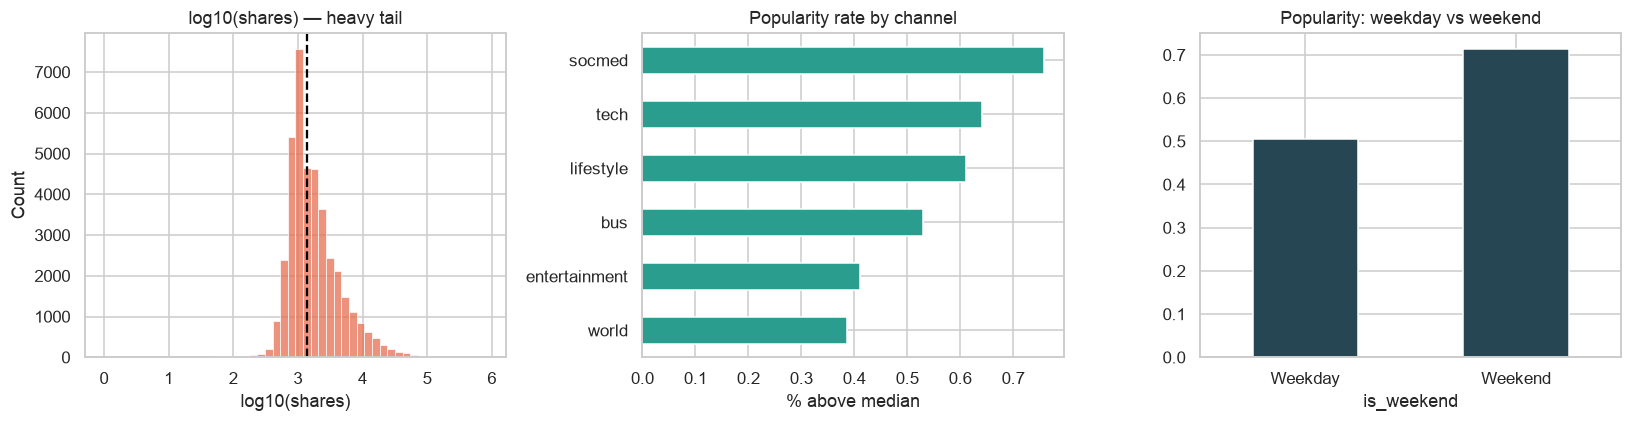

Social-media & tech channels and weekend publishing skew more popular.


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# share distribution (log)
sns.histplot(np.log10(df["shares"].clip(lower=1)), bins=50, ax=ax[0], color="#e76f51")
ax[0].axvline(np.log10(median), ls="--", color="black"); ax[0].set_title("log10(shares) — heavy tail"); ax[0].set_xlabel("log10(shares)")
# popularity by channel
chan = {c: df[df[c]==1]["shares"].ge(median).mean() for c in df.columns if c.startswith("data_channel_is_")}
pd.Series(chan).rename(lambda s: s.replace("data_channel_is_","")).sort_values().plot.barh(ax=ax[1], color="#2a9d8f")
ax[1].set_title("Popularity rate by channel"); ax[1].set_xlabel("% above median")
# weekend vs weekday
wk = df.groupby("is_weekend")["shares"].apply(lambda s: s.ge(median).mean())
wk.rename({0:"Weekday",1:"Weekend"}).plot.bar(ax=ax[2], color="#264653"); ax[2].set_title("Popularity: weekday vs weekend"); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(IMG/"eda_engagement.png", bbox_inches="tight"); plt.show()
print("Social-media & tech channels and weekend publishing skew more popular.")

## 4. Feature preparation & model comparison

In [5]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
def rep(name, model, scaled=False):
    model.fit(Xtr_s if scaled else Xtr, ytr)
    p = model.predict_proba(Xte_s if scaled else Xte)[:,1]; pred=(p>=.5).astype(int)
    return model, p, dict(model=name, accuracy=accuracy_score(yte,pred), f1=f1_score(yte,pred),
                          roc_auc=roc_auc_score(yte,p), pr_auc=average_precision_score(yte,p))
lr,plr,r1 = rep("Logistic Regression", LogisticRegression(max_iter=2000), scaled=True)
rf,prf,r2 = rep("Random Forest", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
xg,pxg,r3 = rep("XGBoost", xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42))
pd.DataFrame([r1,r2,r3]).set_index("model").round(3)

,accuracy,f1,roc_auc,pr_auc
model,,,,
Logistic Regression,0.655,0.684,0.708,0.725
Random Forest,0.662,0.697,0.720,0.741
XGBoost,0.670,0.699,0.734,0.757


In [6]:
cv = cross_val_score(xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42),
        X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc")
print(f"XGBoost 5-fold CV ROC-AUC: {cv.mean():.3f} +/- {cv.std():.3f}")

XGBoost 5-fold CV ROC-AUC: 0.740 +/- 0.003


### ROC & precision-recall curves

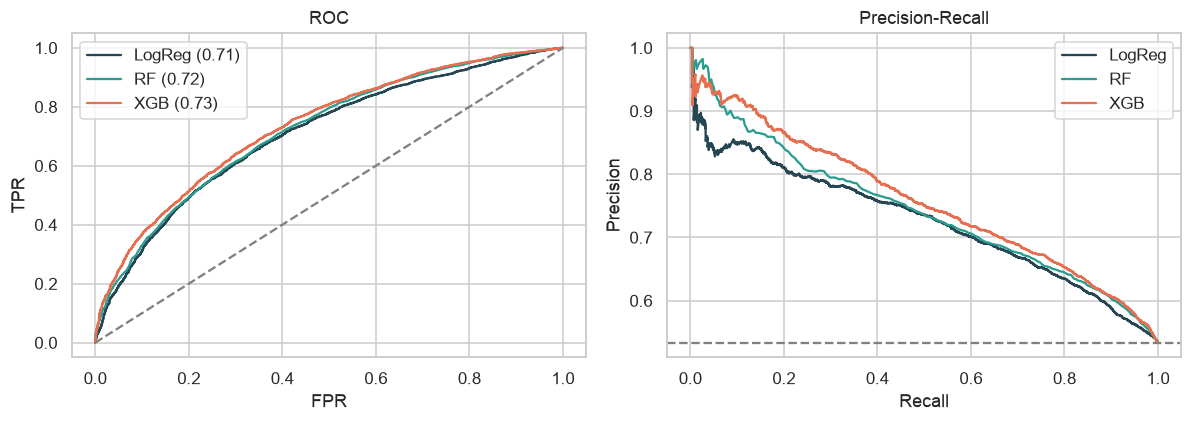

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for p, name, c in [(plr,"LogReg","#264653"),(prf,"RF","#2a9d8f"),(pxg,"XGB","#e76f51")]:
    fpr,tpr,_=roc_curve(yte,p); ax[0].plot(fpr,tpr,label=f"{name} ({roc_auc_score(yte,p):.2f})",color=c)
    pr,rc,_=precision_recall_curve(yte,p); ax[1].plot(rc,pr,label=name,color=c)
ax[0].plot([0,1],[0,1],"--",color="grey"); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].axhline(yte.mean(),ls="--",color="grey"); ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.savefig(IMG/"model_curves.png", bbox_inches="tight"); plt.show()

## 5. What drives shareability — SHAP
The features with cryptic names decode as:
- `kw_avg_avg`, `kw_max_avg` — **keyword strength** (how many shares this article's keywords historically attract);
- `LDA_00…04` — the article's **topic mix** (from topic modelling);
- `self_reference_avg_sharess` — **how popular the articles it links to are**;
- `num_hrefs`, `num_imgs` — links and images.

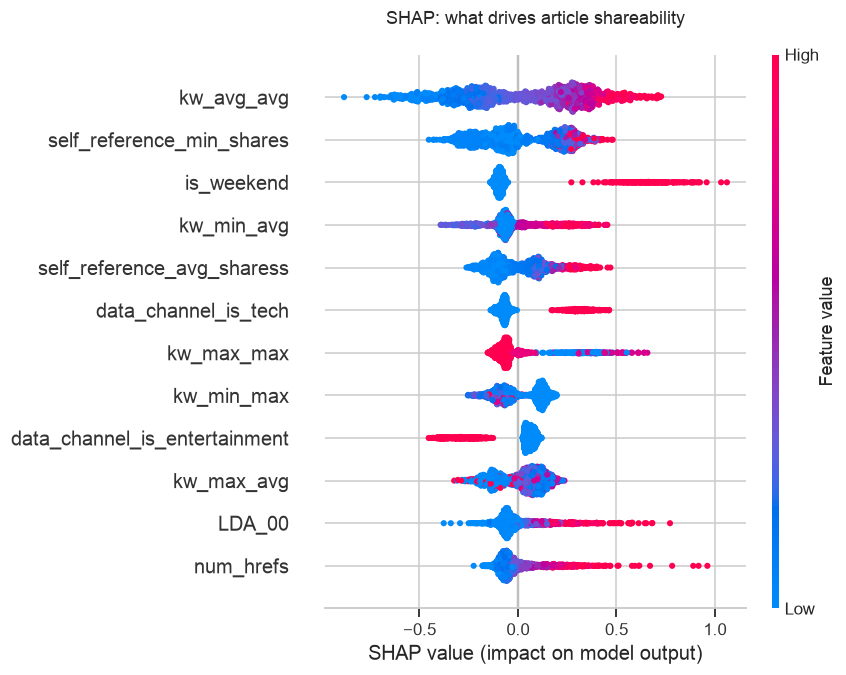

In [8]:
explainer = shap.TreeExplainer(xg)
Xs = Xte.sample(min(1500, len(Xte)), random_state=42)
sv = explainer.shap_values(Xs)
plt.figure(); shap.summary_plot(sv, Xs, show=False, max_display=12)
plt.title("SHAP: what drives article shareability", pad=20)
plt.tight_layout(); plt.savefig(IMG/"shap_summary.png", bbox_inches="tight"); plt.show()

## 6. Business application
The model turns "what makes content spread" into concrete editorial levers:
- **Keyword strength dominates** — choosing topics/keywords with a strong sharing history matters more than article length.
- **Topic mix and channel** — some verticals (social media, tech) reliably out-share others.
- **Reference popular content** — linking to already-popular pieces correlates with more shares.
- **Timing** — weekend publishing shifts the odds.

A content team can score a draft *before* publishing and see which levers to pull.

## 7. Conclusion, limitations & next steps

**What works:** on 39,644 real articles, XGBoost predicts above-median popularity with **ROC-AUC 0.74** (stable under cross-validation), and SHAP surfaces the editorial levers that drive sharing.

**Honest limitations:**
- Predicting virality is genuinely hard — 0.74 AUC is solid for this benchmark, not near-perfect, and reflects how much of sharing is luck/network effects.
- Median-split framing answers "above/below typical", not "mega-viral" (the extreme tail is much harder).
- Features are engineered from article metadata, not the raw text — an NLP/transformer approach on the headlines and body is a natural extension.

**Next steps:** predict the extreme-viral tail (top-decile, with imbalance handling), add transformer embeddings of the headline/body, and a "score-my-draft" Streamlit tool.

---
### 🎤 Interview talking points
- *"Why frame it as above/below median?"* Shares are extremely heavy-tailed; the median split is the standard, stable benchmark. I note the mega-viral tail is a separate, harder problem.
- *"Is 0.74 AUC good?"* Yes for this benchmark — it matches published results and reflects the irreducible randomness in what goes viral.
- *"What's actually actionable?"* SHAP shows keyword strength, topic and referencing popular content beat raw length — concrete editorial levers.
